In [1]:
from ergochemics.mapping import get_reaction_center
from rdkit import Chem
from itertools import accumulate
import numpy as np
from ergochemics.draw import draw_molecule
from IPython.display import display, SVG

In [2]:
def get_reaction_center(am_rxn: str, mode: str = "separate", include_stereo: bool = False) -> list[list[list[int]], list[list[int]]] | list[list[int], list[int]]:
    '''
    Get reaction center from reaction SMARTS with atom mapping.
    
    Args
    ----
    am_rxn:str
        Reaction SMARTS with atom mapping. Must be in the form of
        "R1.R2>>P1.P2" where R1 and R2 are reactants and P1 and P2 are products.
    mode:str
        Mode of operation. If "separate", returns reaction center indices
        for reactants and products separately. If "combined", returns a single
        list of reaction center indices for each side of the reaction.
    
    Returns
    -------
    tuple[tuple[tuple[int]], tuple[tuple[int]]] | tuple[tuple[int], tuple[int]]
        If mode is "separate", returns a tuple of tuples of tuples of reaction center indices
        for each molecule for each side of the reaction.
        If mode is "combined", returns a tuple of tuples of reaction center indices for each side of the reaction,
        treating each side as a combined, disjoint molecule.

    Notes
    -----
    rdkit Chem.MolFromSmiles() indexes atoms in the order they appear in the SMILES string. This
    is true whether the SMILES string has multiple molecules or not.
    '''
    if mode not in ["separate", "combined"]:
        raise ValueError("Mode must be 'separate' or 'combined'")

    sides = [elt.split('.') for elt in am_rxn.split('>>')]
    amn_to_midx_aidx = [] # Atom map num to mol idx, atom idx for lhs, rhs
    adj_mats = []
    offsets = []
    block_mols = []
    for side in sides:
        tmp = {}
        n_atoms = []
        for midx, smi in enumerate(side):
            mol = Chem.MolFromSmiles(smi)
            n_atoms.append(mol.GetNumAtoms())
            
            for atom in mol.GetAtoms():
                amn = atom.GetAtomMapNum()

                if amn == 0:
                    raise ValueError("All atoms in reaction SMARTS must have atom map numbers")

                tmp[amn] = (midx, atom.GetIdx())
        
        amn_to_midx_aidx.append(tmp)
        offsets.append([0] + list(accumulate(n_atoms)))

        block_smi = ".".join(side)
        block_mol = Chem.MolFromSmiles(block_smi)
        block_mols.append(block_mol)
        block_aidx_to_amn = {atom.GetIdx(): atom.GetAtomMapNum() for atom in block_mol.GetAtoms()}
        A = Chem.GetAdjacencyMatrix(mol=block_mol, useBO=True)
        srt_idx = sorted([i for i in range(A.shape[0])], key=lambda x : block_aidx_to_amn[x])
        A = A[:, srt_idx][srt_idx]
        adj_mats.append(A)

    D = np.abs(adj_mats[1] - adj_mats[0])

    if len(amn_to_midx_aidx[0].keys() ^ amn_to_midx_aidx[1].keys()) != 0:
        raise ValueError("LHS and RHS atom maps do not perfectly intersect")

    srt_amns = sorted(amn_to_midx_aidx[0].keys())
    rc_amns = [srt_amns[i] for i in np.flatnonzero(D.sum(axis=1))]

    if include_stereo:
        rc_amns = _add_stereo_double_bond_atoms(block_mols, rc_amns)
        rc_amns = _add_chiral_center_atoms(block_mols, rc_amns)
    if mode == "separate":
        tmp = [[[] for _ in range(len(side))] for side in sides]
        for amn in rc_amns:
            for side_idx, lookup in enumerate(amn_to_midx_aidx):
                midx, aidx = lookup[amn]
                tmp[side_idx][midx].append(aidx)

        reaction_center = tuple([tuple(tuple(sorted(mol_rc)) for mol_rc in side_rc) for side_rc in tmp])
    elif mode == "combined":
        tmp = [[], []]
        for amn in rc_amns:
            for side_idx, lookup in enumerate(amn_to_midx_aidx):
                midx, aidx = lookup[amn]
                tmp[side_idx].append(aidx + offsets[side_idx][midx])

        reaction_center = tuple([tuple(sorted(side_rc)) for side_rc in tmp])

    return reaction_center


In [3]:
rxn = '[C:1](#[C:2][C:3](=[O:4])[H:5])[H:6].[O:7]([C:8](=[O:9])[c:10]1[n:11][c:12]2[c:13]([O:14][H:15])[c:16]([O:17][H:18])[c:19]3[c:20]([c:21]2[c:22]([C:23](=[O:24])[O:25][H:26])[c:27]1[H:28])[n:29]([H:30])[c:31]([C:32](=[O:33])[O:34][H:35])[c:36]3[H:37])[H:38]>>[C:1](#[C:2][C:3]([O:4][H:18])([H:5])[H:15])[H:6].[O:7]([C:8](=[O:9])[c:10]1[n:11][c:12]2[c:21]([c:22]([C:23](=[O:24])[O:25][H:26])[c:27]1[H:28])-[c:20]1[c:19]([c:36]([H:37])[c:31]([C:32](=[O:33])[O:34][H:35])[n:29]1[H:30])[C:16](=[O:17])[C:13]2=[O:14])[H:38]'
tmp = ''
mols = []
for side in rxn.split('>>'):
    for smi in side.split('.'):
        mol = Chem.MolFromSmiles(smi)
        Chem.RemoveHs(mol)
        mols.append(mol)
        smi = Chem.MolToSmiles(mol)
        tmp += smi + '.'
    tmp = tmp[:-1] + '>>'
tmp = tmp[:-2]
rxn = tmp

In [4]:
rxn

'[CH:1]#[C:2][CH:3]=[O:4].[OH:7][C:8](=[O:9])[c:10]1[n:11][c:12]2[c:13]([OH:14])[c:16]([OH:17])[c:19]3[c:20]([c:21]2[c:22]([C:23](=[O:24])[OH:25])[cH:27]1)[nH:29][c:31]([C:32](=[O:33])[OH:34])[cH:36]3>>[CH:1]#[C:2][CH2:3][OH:4].[OH:7][C:8](=[O:9])[c:10]1[n:11][c:12]2[c:21]([c:22]([C:23](=[O:24])[OH:25])[cH:27]1)-[c:20]1[c:19]([cH:36][c:31]([C:32](=[O:33])[OH:34])[nH:29]1)[C:16](=[O:17])[C:13]2=[O:14]'

In [5]:
get_reaction_center(rxn)

(((2, 3), (5, 6, 7, 8, 9, 10, 11, 12)),
 ((2, 3), (5, 6, 12, 13, 20, 21, 22, 23)))

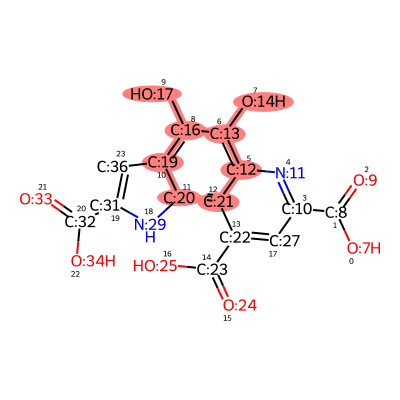

In [6]:
display(SVG(draw_molecule(
    mols[1],
    highlight_atoms=(5, 6, 7, 8, 9, 10, 11, 12),
    size=(400, 400),
    draw_options={"addAtomIndices": True}
)))

In [7]:
mols[1].GetBondBetweenAtoms(11, 12).GetBondType()

rdkit.Chem.rdchem.BondType.AROMATIC

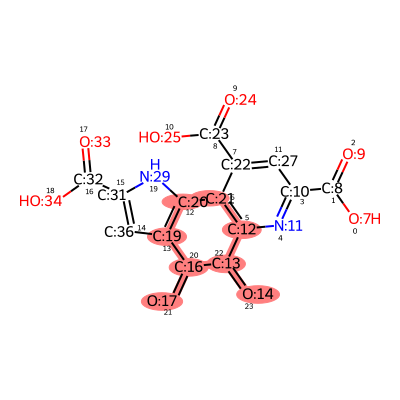

In [8]:
display(SVG(draw_molecule(
    mols[3],
    highlight_atoms=(5, 6, 12, 13, 20, 21, 22, 23),
    size=(400, 400),
    draw_options={"addAtomIndices": True}
)))

In [9]:
mols[3].GetBondBetweenAtoms(5, 22).GetBondType()

rdkit.Chem.rdchem.BondType.SINGLE

In [10]:
rxn2 = "[C:1][C:3]=[O:5]>>[C:1][C:3][O:5]"
get_reaction_center(rxn2)

(((1, 2),), ((1, 2),))